In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import random

In [2]:
df = pd.read_csv('datasets/Titanic-Dataset.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
n = 120

age = np.random.randint(18,61,n)
income = np.random.normal(55000, 15000, n).clip(20000, 120000)
purchases = np.random.poisson(5,n) + 1
spending = (income + np.random.uniform(0.02, 0.10 ,n) + purchases * np.random.uniform(150,500, n))

satisfaction = np.random.normal(7,1.2, n).clip(1,10)

df = pd.DataFrame({'Cus_ID': range(1, n + 1),
                   'Age' : age,
                   'Monthly_Income' : income.round(0),
                   'Purchases' : purchases,
                'Total_Spending' : spending.round(0),
                'Satisfaction_score' : satisfaction.round(0)})

In [5]:
df.head()

,Cus_ID,Age,Monthly_Income,Purchases,Total_Spending,Satisfaction_score
0,1,23,39708.0,7,42492.0,8.0
1,2,42,41157.0,9,43866.0,6.0
2,3,44,20000.0,7,22615.0,5.0
3,4,47,40705.0,2,41467.0,5.0
4,5,41,48388.0,5,49442.0,7.0


In [6]:
df.shape

(120, 6)

In [7]:
mean_spending = df['Total_Spending'].mean()
mean_spending

np.float64(55721.325)

In [8]:
median_spending = df['Total_Spending'].median()
print(f'Median spending = {median_spending:,.2f}')

Median spending = 55,312.50


In [9]:
print('Purchase count frequencies: ')
print(df['Purchases'].value_counts().sort_index())

Purchase count frequencies: 
Purchases
1      3
2      4
3      7
4     11
5     24
6     21
7     24
8     10
9      9
10     5
11     1
14     1
Name: count, dtype: int64


In [10]:
mode_purchases = df['Purchases'].mode()[0]
print(f"Most common number of purchase = {mode_purchases}")

Most common number of purchase = 5


In [11]:
income_range = df['Monthly_Income'].max() - df['Monthly_Income'].min()
income_range

np.float64(69197.0)

In [12]:
income_variance = df["Monthly_Income"].var()
income_variance

np.float64(228079088.58816528)

In [13]:
income_std = df['Monthly_Income'].std()
income_std

np.float64(15102.287528323823)

Normal distribution is a bell shaped symmetric curve which tells us that our data is normally distributed.

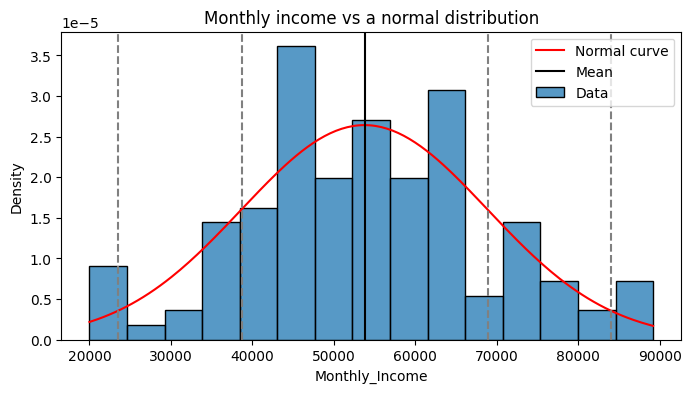

In [14]:
mu, sigma = df['Monthly_Income'].mean(), df['Monthly_Income'].std()
x = np.linspace(df['Monthly_Income'].min(), df['Monthly_Income'].max(), 200)
pdf = np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) / (sigma * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 4))
sns.histplot(df['Monthly_Income'], bins=15, stat='density', label='Data')
plt.plot(x, pdf, color='red', label='Normal curve')
for k in (1, 2):
    plt.axvline(mu - k * sigma, ls='--', color='grey'); plt.axvline(mu + k * sigma, ls='--', color='grey')
plt.axvline(mu, color='black', label='Mean')
plt.title('Monthly income vs a normal distribution')
plt.legend(); plt.show()

**Empirical (68-95-99.7) rule.** For normal data, about 68% of values lie within 1σ of the mean, 95% within 2σ and 99.7% within 3σ.

In [15]:
for k in (1, 2, 3):
    within = df['Monthly_Income'].between(mu - k * sigma, mu + k * sigma).mean() * 100
    print(f'within {k} std: {within:.1f}%')

within 1 std: 70.0%
within 2 std: 93.3%
within 3 std: 100.0%


In [16]:
# Skewness: ~0 means symmetric (normal-like), > 0 right tail, < 0 left tail
print('Income skew   :', round(df['Monthly_Income'].skew(), 2))
print('Purchases skew:', round(df['Purchases'].skew(), 2), '(Poisson counts are right-skewed)')

Income skew   : 0.09
Purchases skew: 0.22 (Poisson counts are right-skewed)


In [17]:
# Z-score: how many standard deviations a value is from the mean
df['Income_Z'] = (df['Monthly_Income'] - mu) / sigma
print('customers more than 2 std from the mean:', (df['Income_Z'].abs() > 2).sum())
df[['Cus_ID', 'Monthly_Income', 'Income_Z']].sort_values('Income_Z').head()

customers more than 2 std from the mean: 8


,Cus_ID,Monthly_Income,Income_Z
2,3,20000.0,-2.235969
7,8,20000.0,-2.235969
98,99,20000.0,-2.235969
107,108,20000.0,-2.235969
119,120,23834.0,-1.982100


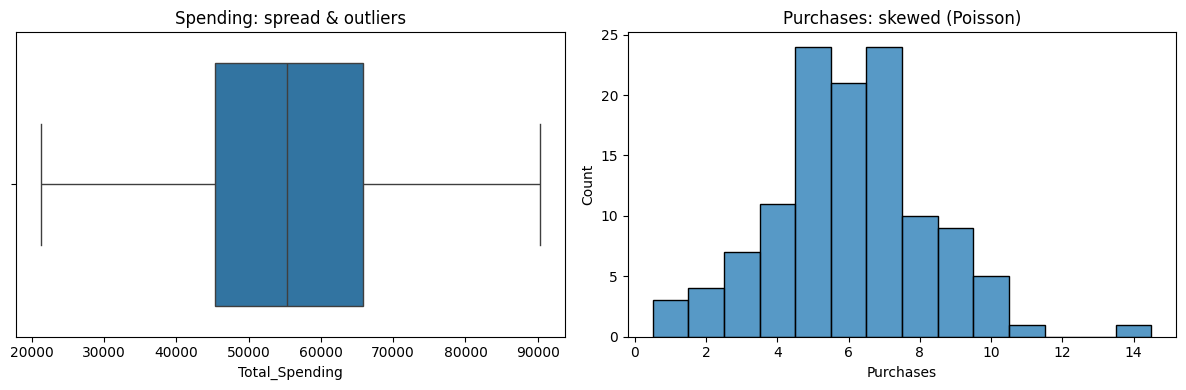

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Total_Spending'], ax=ax[0]); ax[0].set_title('Spending: spread & outliers')
sns.histplot(df['Purchases'], discrete=True, ax=ax[1]); ax[1].set_title('Purchases: skewed (Poisson)')
plt.tight_layout(); plt.show()